In [9]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import numpy as np

In [10]:
import os 

path = os.path.join("..", "data_processed", "nazare_cleaned_final.parquet")

df = pd.read_parquet(path)

df.head()

,valid_time,surface_heat_flux,wave_direction_deg,mean_wave_period_s,wave_height_m,peak_wave_period_s,air_temp_c,sea_surface_temp_c,dew_point_temp_c,wind_speed_kmh,pressure_hpa,wind_direction,year,month,day,hour
0,2000-01-01 00:00:00,-17.092773,327.884796,8.214509,1.382858,9.931007,11.639465,15.322968,7.360016,19.002850,1027.466553,NE,2000,1,1,0
1,2000-01-01 06:00:00,-14.455933,323.430359,8.842020,1.305284,13.316505,11.423126,15.322968,7.680603,15.353812,1027.223877,NE,2000,1,1,6
2,2000-01-01 12:00:00,-25.772461,316.730377,10.025695,1.339482,13.428322,12.371857,15.322968,6.155243,11.941938,1029.079956,NE,2000,1,1,12
3,2000-01-01 18:00:00,-14.737640,311.361450,11.419249,1.656322,14.627785,11.766083,15.322968,6.931580,18.247585,1027.753174,N,2000,1,1,18
4,2000-01-02 00:00:00,-17.002182,309.866638,12.182859,2.160654,14.639992,11.860321,15.337463,7.155029,19.236988,1028.427002,NE,2000,1,2,0


The research question is:

Analysis of the factors determining the occurrence of extreme waves in the Nazaré region: Do changes in atmospheric dynamics over the period 2000–2019 influence the extreme wave heights reaching the coast?

The following analyses will be conducted to answer this question:

- Descriptive Analysis: Description of parameters closely correlated with waves.
- Diagnostic Analysis: Analysis of the formation of extreme wave phenomena.
- Seasonal Analysis: Determination of the times when the risk of extreme wave events is highest.
- Predictive Analysis: The XGBoost model as a tool for forecasting and predicting possible phenomena.

# Descriptive Analysis:

The first step is to encode the wind direction column using One Hot Encoding, this will allow us to determine whether the wind direction has a significant effect on the wave height.

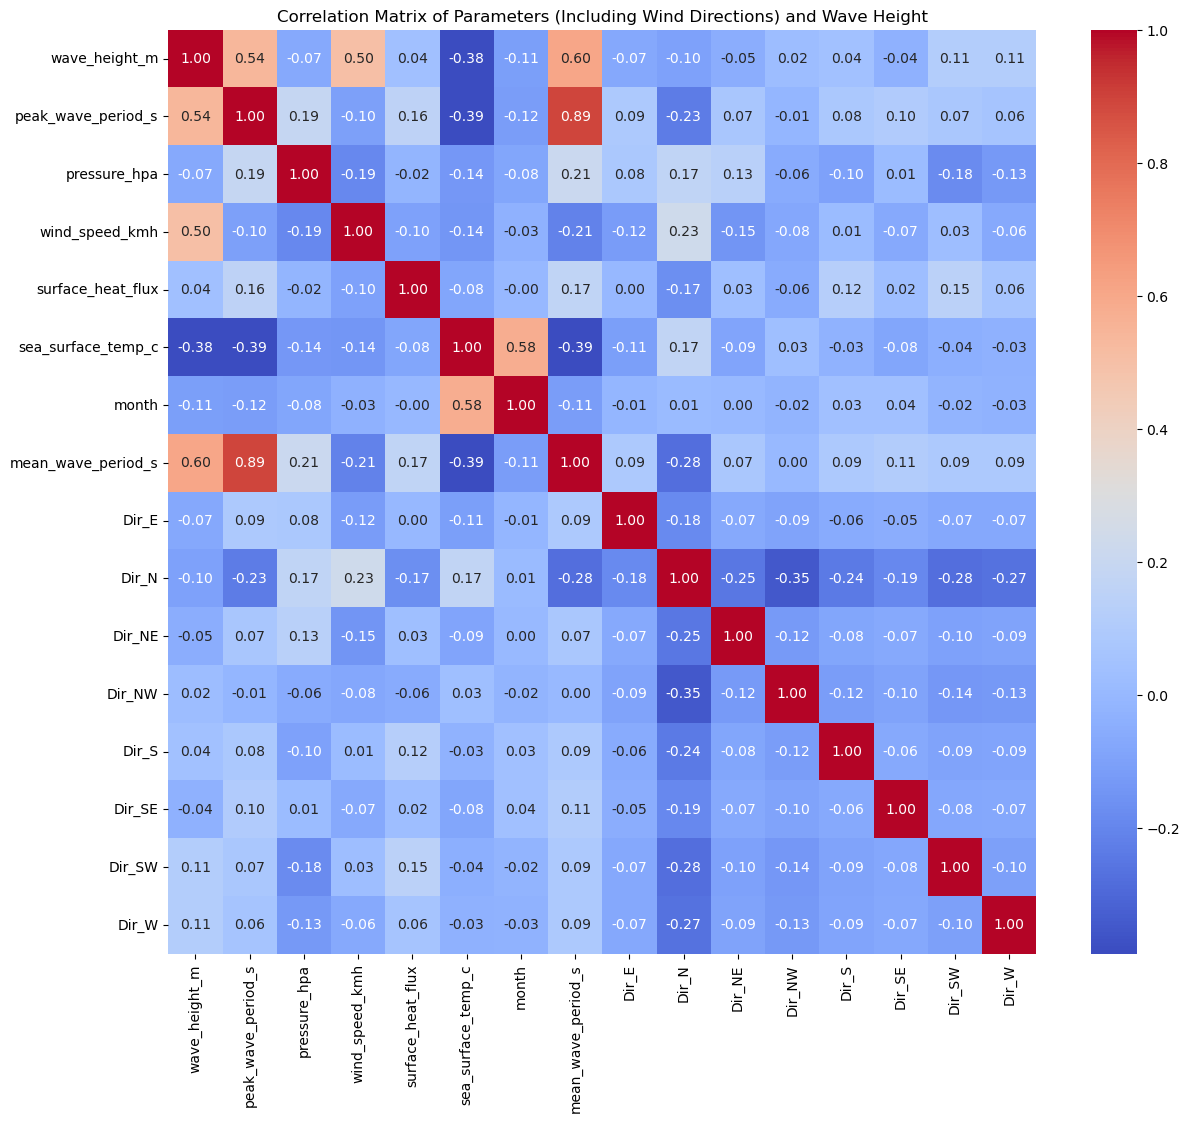

In [11]:
df_heatmap = pd.get_dummies(df, columns=['wind_direction'], prefix='Dir')


diagnostic_variables = [
    'wave_height_m', 
    'peak_wave_period_s', 
    'pressure_hpa', 
    'wind_speed_kmh', 
    'surface_heat_flux',
    'sea_surface_temp_c',
    'month',
    'mean_wave_period_s'
] + [col for col in df_heatmap.columns if col.startswith('Dir_')]


plt.figure(figsize=(14, 12))
sns.heatmap(df_heatmap[diagnostic_variables].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Parameters (Including Wind Directions) and Wave Height')
plt.savefig('Wykres_korelacji_zmienne_przewidywane.png')
plt.show()

The next step is to show the relationship of Peak Period vs Wave Height.

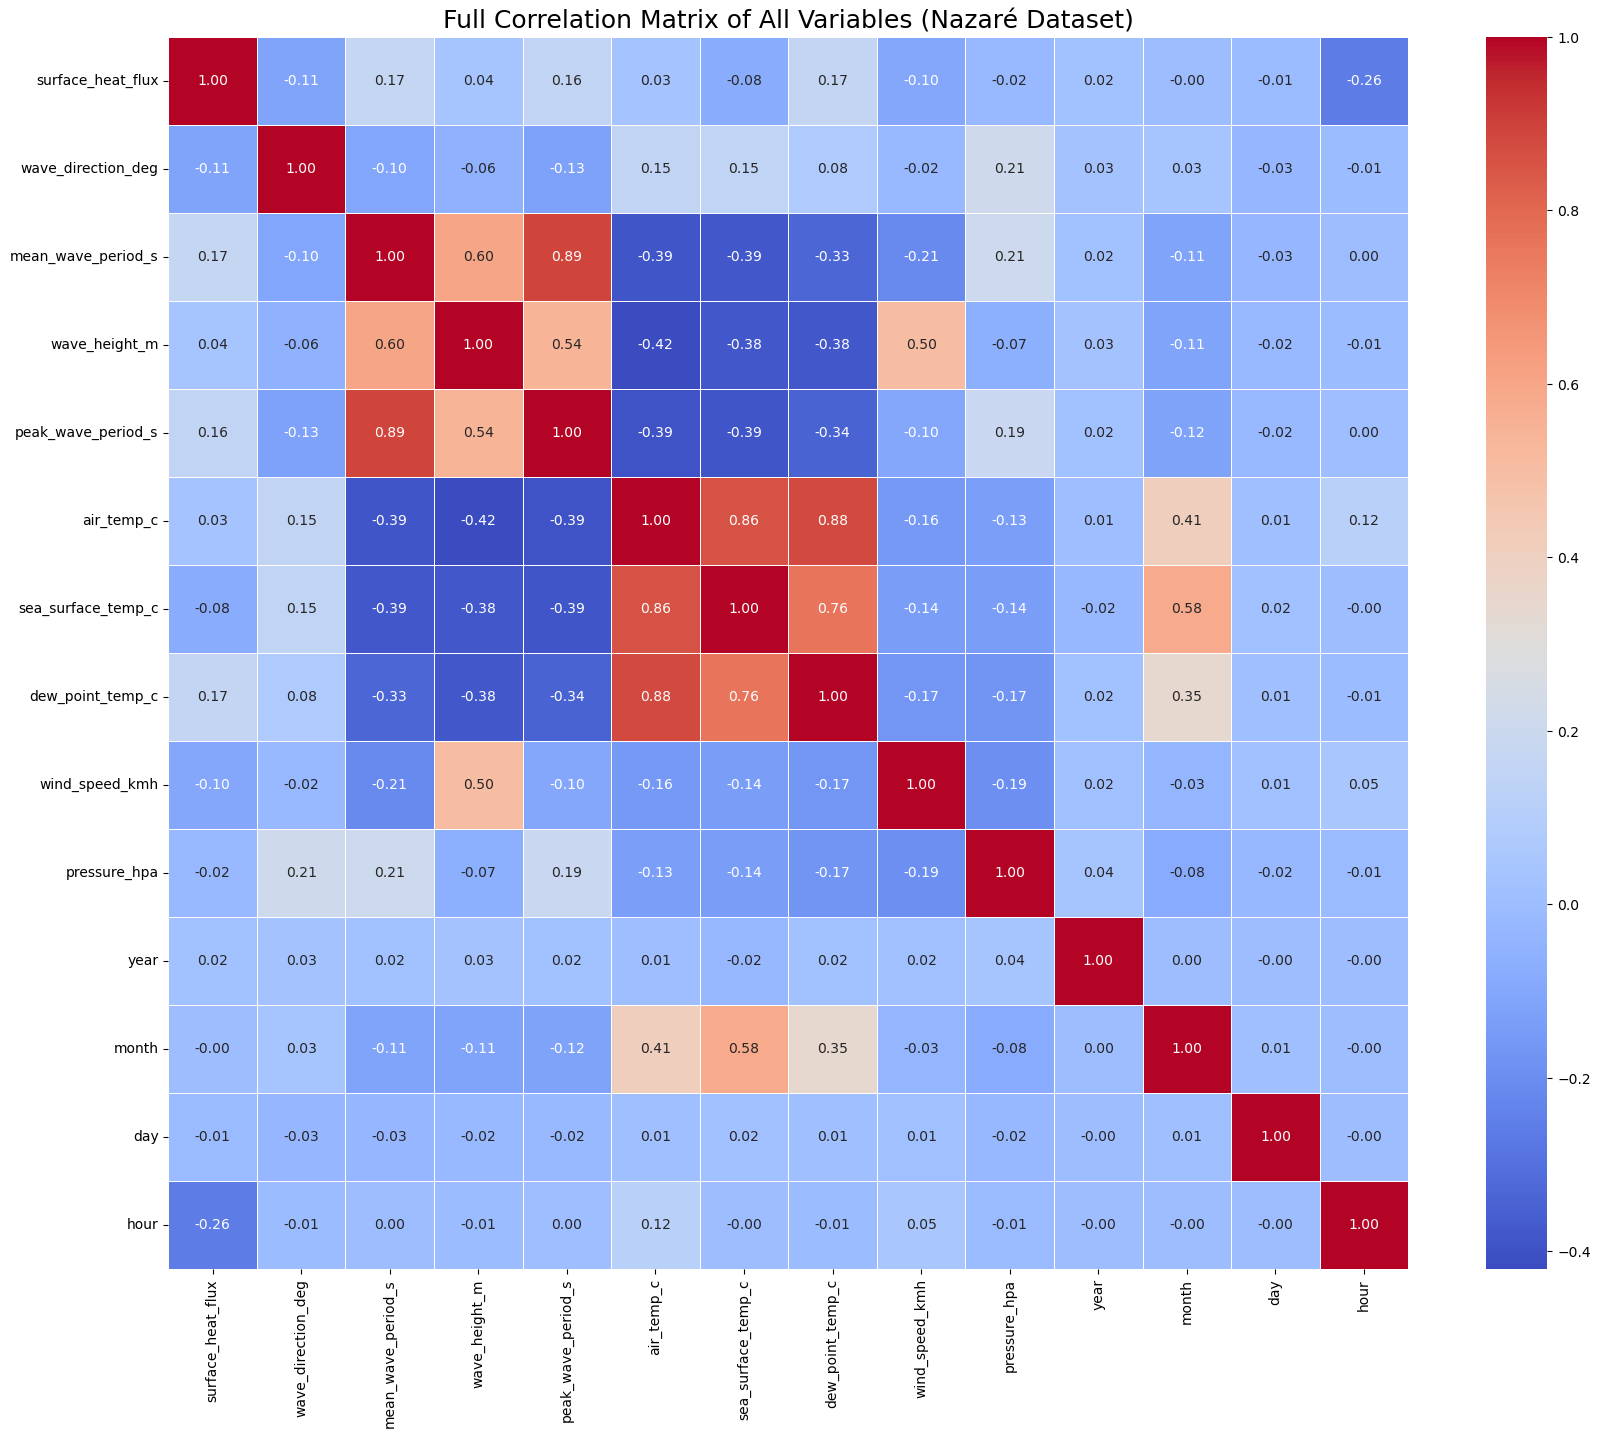

In [13]:
df_all_corr = pd.get_dummies(df, columns=['wind_direction'], prefix='Dir')

full_correlation_matrix = df_all_corr.select_dtypes(include=['number']).corr()


plt.figure(figsize=(20, 16)) 
sns.heatmap(
    full_correlation_matrix, 
    annot=True,               
    cmap='coolwarm',          
    fmt=".2f",                
    linewidths=0.5           
)

plt.title('Full Correlation Matrix of All Variables (Nazaré Dataset)', fontsize=18)
plt.savefig("Full_correlation_graph.png")
plt.show()



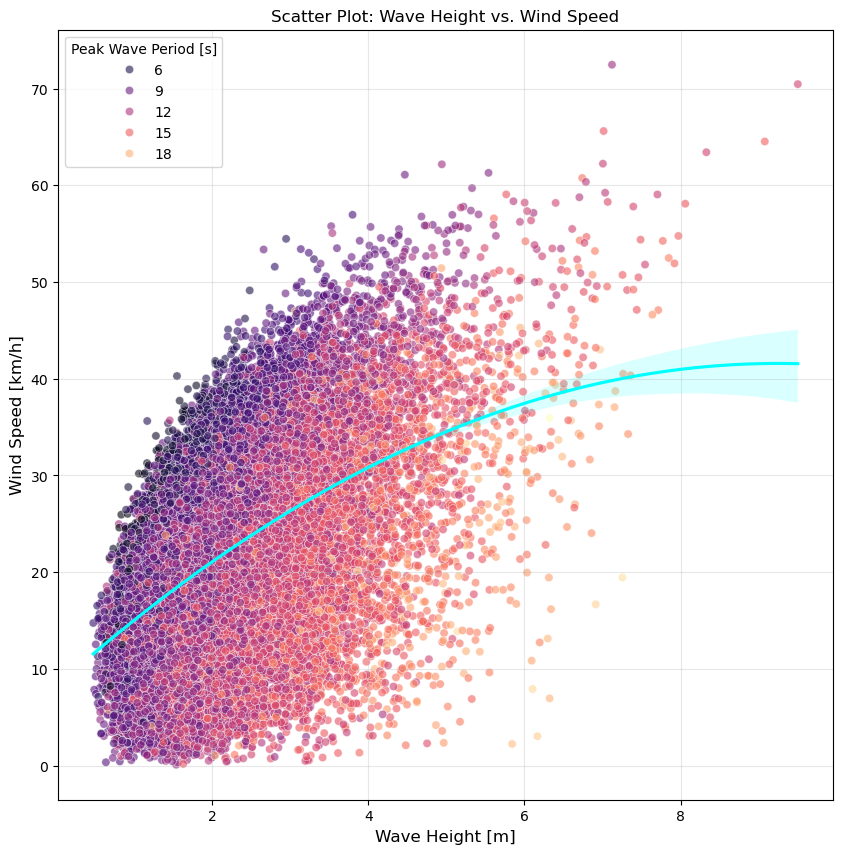

In [14]:
plt.figure(figsize=(10, 10))

ax = sns.scatterplot(
    data=df,
    x='wave_height_m',
    y='wind_speed_kmh',
    hue='peak_wave_period_s',
    palette='magma',
    alpha=0.6
)

sns.regplot(
    data=df,
    x='wave_height_m',
    y='wind_speed_kmh',
    scatter=False,
    order=2,
    color='cyan',
    ax=ax
)

ax.set_title('Scatter Plot: Wave Height vs. Wind Speed')
ax.set_xlabel('Wave Height [m]', fontsize=12)
ax.set_ylabel('Wind Speed [km/h]', fontsize=12)
ax.grid(True, alpha=0.3)

ax.legend(title='Peak Wave Period [s]')

plt.show()

In [9]:
print(df['wave_height_m'].max())

9.49985122680664


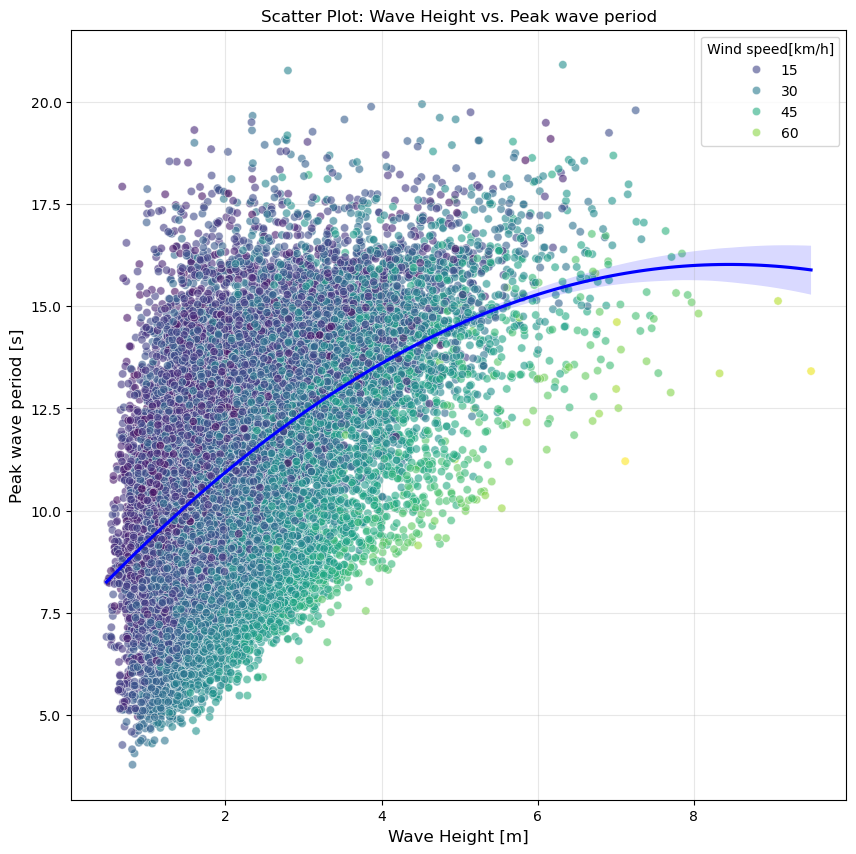

In [15]:
plt.figure(figsize=(10, 10))


ax = sns.scatterplot(data=df, x='wave_height_m', y='peak_wave_period_s', 
                hue='wind_speed_kmh', palette='viridis', alpha=0.6)


sns.regplot(data=df, x='wave_height_m', y='peak_wave_period_s', 
            scatter=False, order=2, color='blue', ax=ax)

ax.set_title('Scatter Plot: Wave Height vs. Peak wave period')
ax.set_xlabel('Wave Height [m]', fontsize=12)
ax.set_ylabel('Peak wave period [s]', fontsize=12)
ax.grid(True, alpha=0.3)

ax.legend(title='Wind speed[km/h]')

plt.savefig("Scatterplot_peak.png")
plt.show()


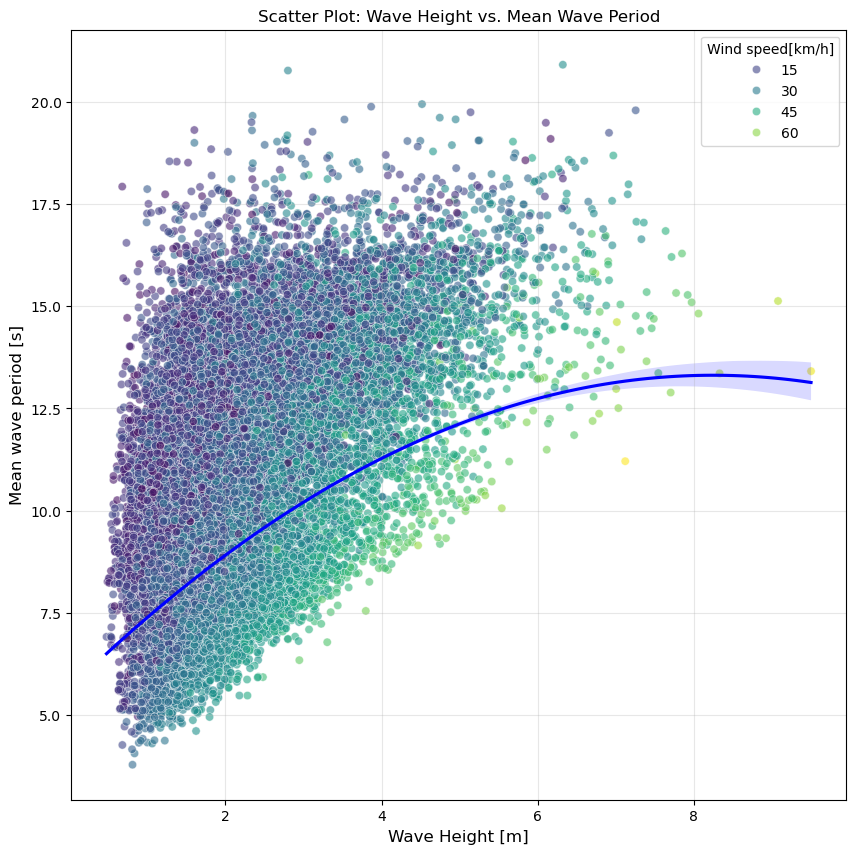

In [16]:
plt.figure(figsize=(10, 10))


ax = sns.scatterplot(data=df, x='wave_height_m', y='peak_wave_period_s', 
                hue='wind_speed_kmh', palette='viridis', alpha=0.6)


sns.regplot(data=df, x='wave_height_m', y='mean_wave_period_s', 
            scatter=False, order=2, color='blue', ax=ax)

ax.set_title('Scatter Plot: Wave Height vs. Mean Wave Period')
ax.set_xlabel('Wave Height [m]', fontsize=12)
ax.set_ylabel('Mean wave period [s]', fontsize=12)
ax.grid(True, alpha=0.3)

ax.legend(title='Wind speed[km/h]')
plt.savefig("Scatterplot_mean.png")
plt.show()

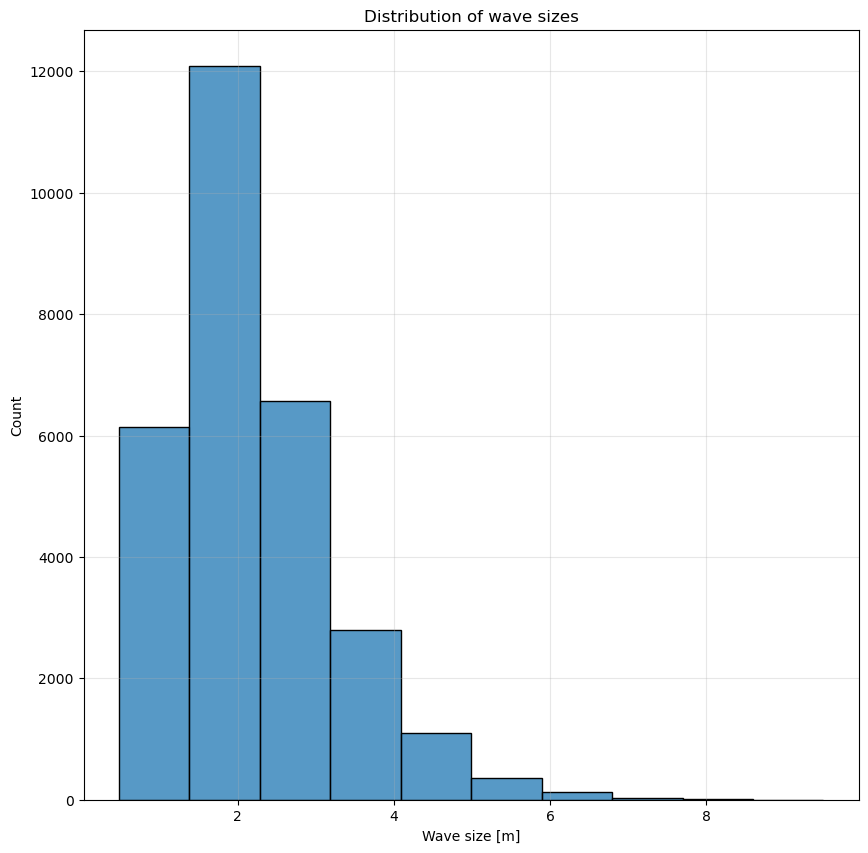

In [17]:
plt.figure(figsize = (10,10))

sns.histplot(data = df, x = 'wave_height_m', bins = 10 )

plt.title('Distribution of wave sizes')
plt.xlabel('Wave size [m]')
plt.ylabel('Count')
plt.grid(True, alpha = 0.3)
plt.show()


# Diagnostic Analysis:

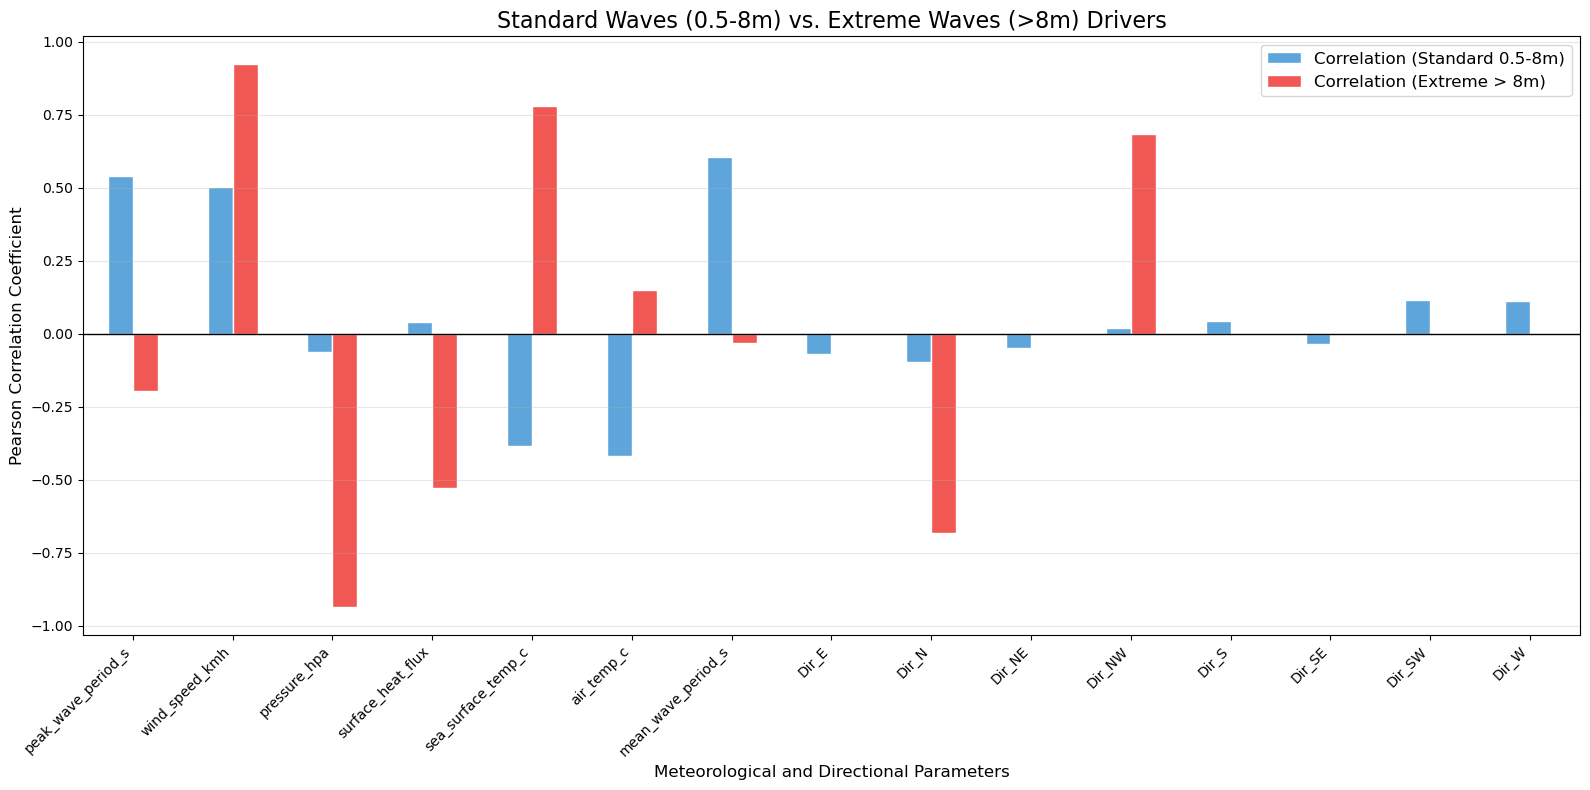

In [18]:

df_ml = pd.get_dummies(df, columns=['wind_direction'], prefix='Dir')


base_features = [
    'peak_wave_period_s', 
    'wind_speed_kmh', 
    'pressure_hpa', 
    'surface_heat_flux', 
    'sea_surface_temp_c',
    'air_temp_c',
    'mean_wave_period_s'
    
]


direction_cols = [col for col in df_ml.columns if col.startswith('Dir_')]
analysis_features = base_features + direction_cols


df_standard = df_ml[(df_ml['wave_height_m'] >= 0.5) & (df_ml['wave_height_m'] <= 8)]


df_extreme = df_ml[df_ml['wave_height_m'] > 8.0]


corr_standard = df_standard[analysis_features + ['wave_height_m']].corr()['wave_height_m'].drop('wave_height_m')
corr_extreme = df_extreme[analysis_features + ['wave_height_m']].corr()['wave_height_m'].drop('wave_height_m')


comparison = pd.DataFrame({
    'Feature': analysis_features,
    'Correlation (Standard 0.5-8m)': corr_standard.values,
    'Correlation (Extreme > 8m)': corr_extreme.values
}).set_index('Feature')


ax = comparison.plot(
    kind='bar', 
    figsize=(16, 8), 
    color=['#5DA5DA', '#F15854'],
    edgecolor='white'
)

plt.title('Standard Waves (0.5-8m) vs. Extreme Waves (>8m) Drivers', fontsize=16)
plt.ylabel('Pearson Correlation Coefficient', fontsize=12)
plt.xlabel('Meteorological and Directional Parameters', fontsize=12)
plt.axhline(0, color='black', linewidth=1.0) 
plt.legend(fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Correlation_change_8m.png')
plt.show()

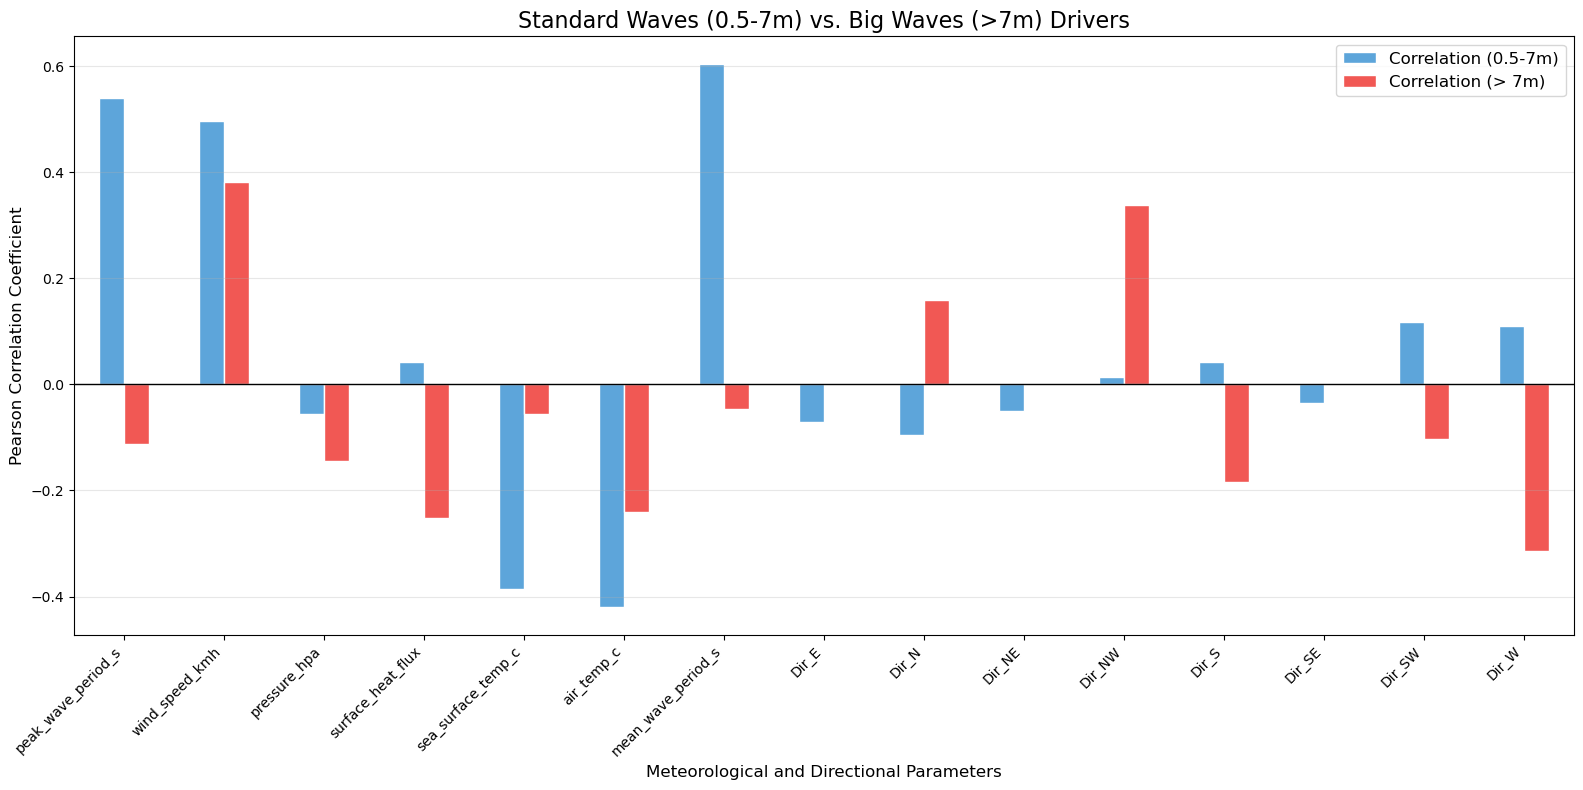

In [19]:

df_ml = pd.get_dummies(df, columns=['wind_direction'], prefix='Dir')


base_features = [
    'peak_wave_period_s', 
    'wind_speed_kmh', 
    'pressure_hpa', 
    'surface_heat_flux', 
    'sea_surface_temp_c',
    'air_temp_c',
    'mean_wave_period_s'
    
]


direction_cols = [col for col in df_ml.columns if col.startswith('Dir_')]
analysis_features = base_features + direction_cols


df_standard = df_ml[(df_ml['wave_height_m'] >= 0.5) & (df_ml['wave_height_m'] <= 7)]


df_extreme = df_ml[df_ml['wave_height_m'] > 7.0]


corr_standard = df_standard[analysis_features + ['wave_height_m']].corr()['wave_height_m'].drop('wave_height_m')
corr_extreme = df_extreme[analysis_features + ['wave_height_m']].corr()['wave_height_m'].drop('wave_height_m')


comparison = pd.DataFrame({
    'Feature': analysis_features,
    'Correlation (0.5-7m)': corr_standard.values,
    'Correlation (> 7m)': corr_extreme.values
}).set_index('Feature')


ax = comparison.plot(
    kind='bar', 
    figsize=(16, 8), 
    color=['#5DA5DA', '#F15854'],
    edgecolor='white'
)

plt.title('Standard Waves (0.5-7m) vs. Big Waves (>7m) Drivers', fontsize=16)
plt.ylabel('Pearson Correlation Coefficient', fontsize=12)
plt.xlabel('Meteorological and Directional Parameters', fontsize=12)
plt.axhline(0, color='black', linewidth=1.0) # Zero line
plt.legend(fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Correlation_change_7m.png')
plt.show()

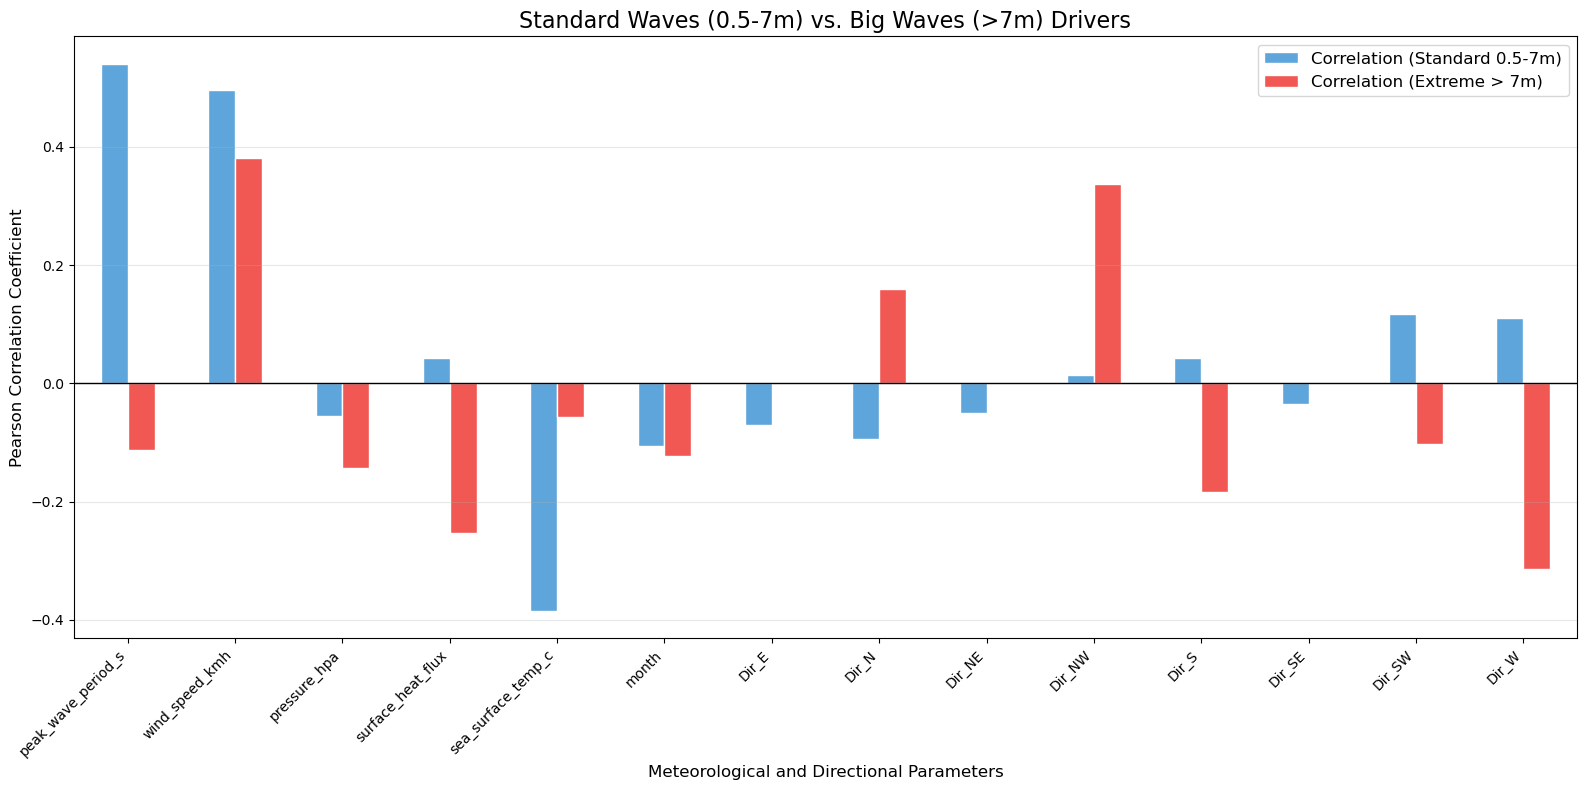

In [20]:
df_monthly = pd.get_dummies(df, columns=['wind_direction'], prefix='Dir')


base_features_month = [
    'peak_wave_period_s', 
    'wind_speed_kmh', 
    'pressure_hpa', 
    'surface_heat_flux', 
    'sea_surface_temp_c',
    'month'
]


direction_cols_month = [col for col in df_ml.columns if col.startswith('Dir_')]
analysis_features_month = base_features_month + direction_cols_month


df_standard_month = df_monthly[(df_monthly['wave_height_m'] >= 0.5) & (df_monthly['wave_height_m'] <= 7)]


df_extreme_month = df_monthly[df_monthly['wave_height_m'] > 7.0]


corr_standard_month = df_standard_month[analysis_features_month+ ['wave_height_m']].corr()['wave_height_m'].drop('wave_height_m')
corr_extreme_month = df_extreme_month[analysis_features_month + ['wave_height_m']].corr()['wave_height_m'].drop('wave_height_m')


comparison_month = pd.DataFrame({
    'Feature': analysis_features_month,
    'Correlation (Standard 0.5-7m)': corr_standard_month.values,
    'Correlation (Extreme > 7m)': corr_extreme_month.values
}).set_index('Feature')


ax = comparison_month.plot(
    kind='bar', 
    figsize=(16, 8), 
    color=['#5DA5DA', '#F15854'],
    edgecolor='white'
)

plt.title('Standard Waves (0.5-7m) vs. Big Waves (>7m) Drivers', fontsize=16)
plt.ylabel('Pearson Correlation Coefficient', fontsize=12)
plt.xlabel('Meteorological and Directional Parameters', fontsize=12)
plt.axhline(0, color='black', linewidth=1.0) # Zero line
plt.legend(fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

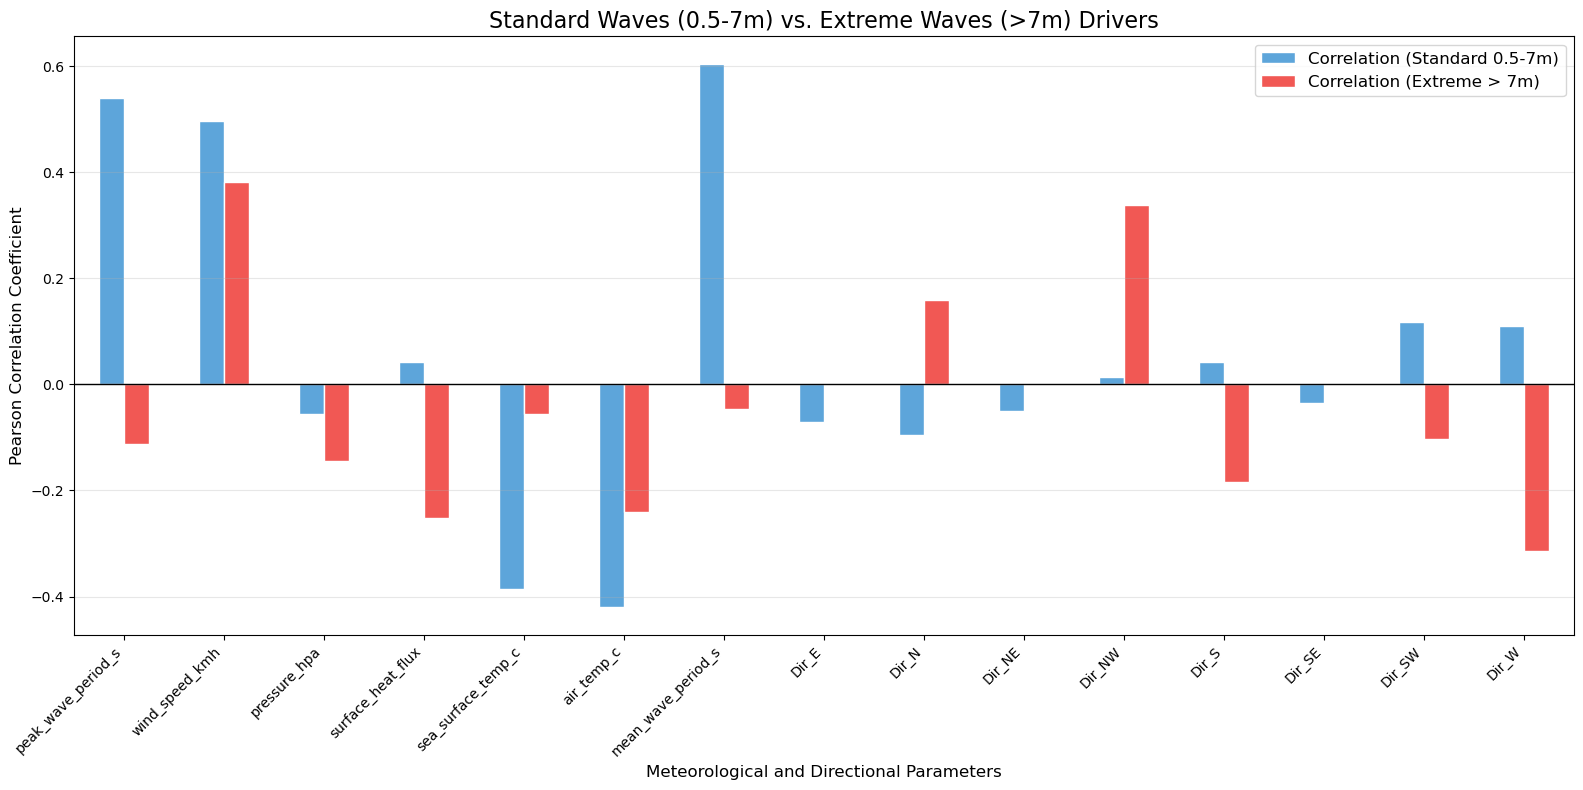

In [21]:


df_monthly = pd.get_dummies(df, columns=['wind_direction'], prefix='Dir')


base_features_month = [
    'peak_wave_period_s', 
    'wind_speed_kmh', 
    'pressure_hpa', 
    'surface_heat_flux', 
    'sea_surface_temp_c',
    'air_temp_c',
    'mean_wave_period_s'
]


direction_cols_month = [col for col in df_ml.columns if col.startswith('Dir_')]
analysis_features_month = base_features_month + direction_cols_month


df_standard_month = df_monthly[(df_monthly['wave_height_m'] >= 0.5) & (df_monthly['wave_height_m'] <= 7)]


df_extreme_month = df_monthly[df_monthly['wave_height_m'] > 7.0]


corr_standard_month = df_standard_month[analysis_features_month+ ['wave_height_m']].corr()['wave_height_m'].drop('wave_height_m')
corr_extreme_month = df_extreme_month[analysis_features_month + ['wave_height_m']].corr()['wave_height_m'].drop('wave_height_m')


comparison_month = pd.DataFrame({
    'Feature': analysis_features_month,
    'Correlation (Standard 0.5-7m)': corr_standard_month.values,
    'Correlation (Extreme > 7m)': corr_extreme_month.values
}).set_index('Feature')


ax = comparison_month.plot(
    kind='bar', 
    figsize=(16, 8), 
    color=['#5DA5DA', '#F15854'],
    edgecolor='white'
)

plt.title('Standard Waves (0.5-7m) vs. Extreme Waves (>7m) Drivers', fontsize=16)
plt.ylabel('Pearson Correlation Coefficient', fontsize=12)
plt.xlabel('Meteorological and Directional Parameters', fontsize=12)
plt.axhline(0, color='black', linewidth=1.0) # Zero line
plt.legend(fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Seasonal Analysis:

Boxplots will be created to illustrate the seasonality of wave phenomena

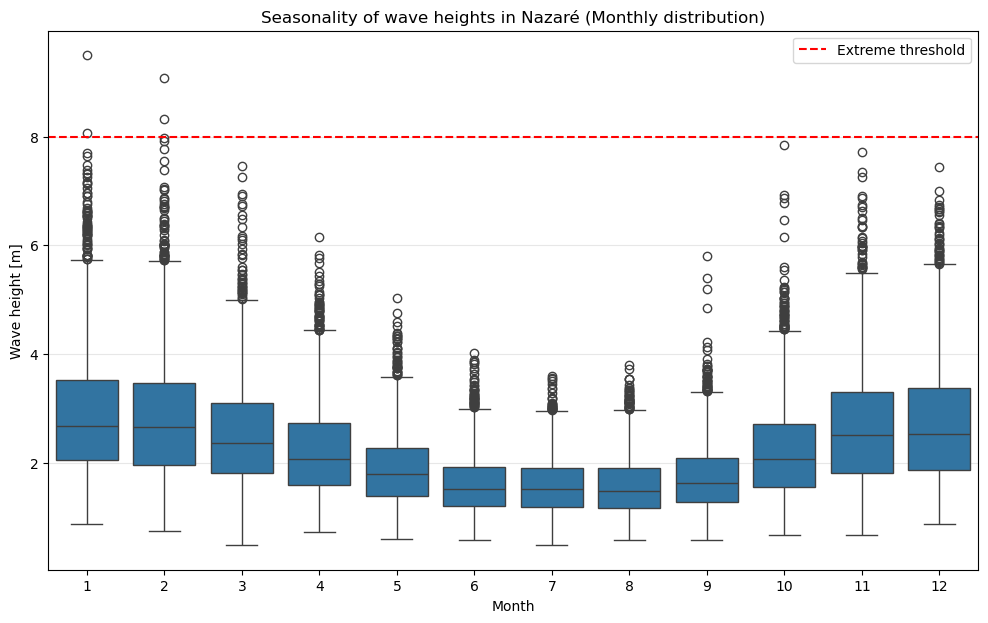

In [22]:
plt.figure(figsize = (12,7))
sns.boxplot(data = df, x='month', y='wave_height_m')
plt.axhline(8, color='red', linestyle='--', label='Extreme threshold')

plt.title('Seasonality of wave heights in Nazaré (Monthly distribution)')
plt.xlabel('Month')
plt.ylabel('Wave height [m]')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig('Month_season_8m.png')
plt.show()


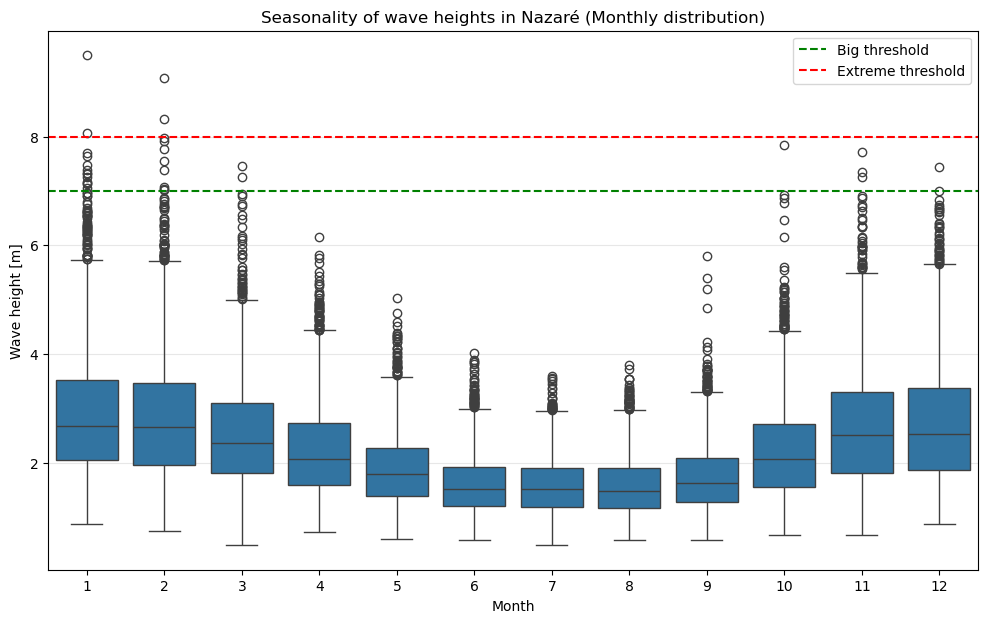

In [23]:
plt.figure(figsize = (12,7))
sns.boxplot(data = df, x='month', y='wave_height_m')
plt.axhline(7, color='green', linestyle='--', label='Big threshold')
plt.axhline(8, color='red', linestyle='--', label='Extreme threshold')
plt.title('Seasonality of wave heights in Nazaré (Monthly distribution)')
plt.xlabel('Month')
plt.ylabel('Wave height [m]')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig('Month_season.png')
plt.show()


In [24]:
ekstrema = df.loc[df['wave_height_m'] > 8, 'valid_time']
print(ekstrema)

1575    2001-01-28 18:00:00
16260   2011-02-17 00:00:00
19070   2013-01-19 12:00:00
20616   2014-02-10 00:00:00
Name: valid_time, dtype: datetime64[ns]


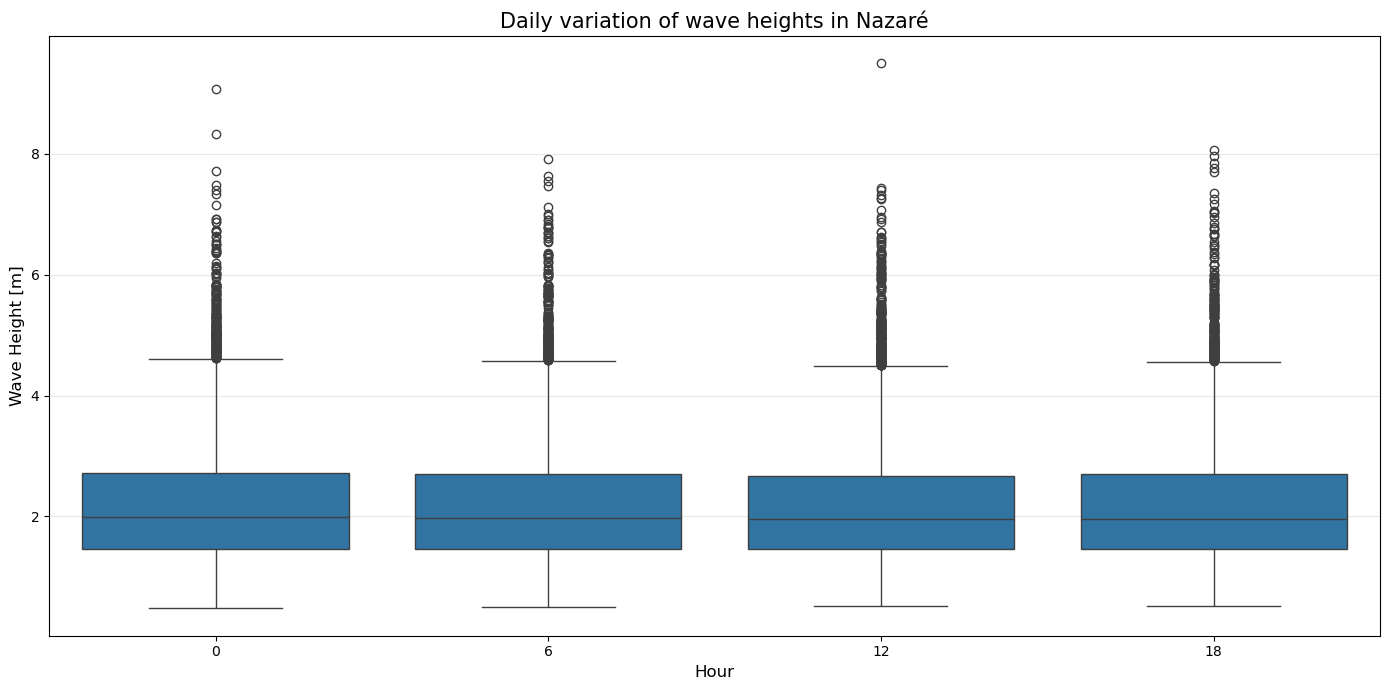

In [25]:
df['Hour'] = pd.to_datetime(df['valid_time']).dt.hour

plt.figure(figsize=(14, 7))
sns.boxplot(data=df, x='Hour', y='wave_height_m')

plt.title('Daily variation of wave heights in Nazaré', fontsize=15)
plt.xlabel('Hour', fontsize=12)
plt.ylabel('Wave Height [m]', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('Daily_season_')
plt.show()

Record waves (> 8 m) do not occur at one specific time, confirming the previous diagnosis: it is the synergy of low pressure and NW wind that is the trigger, not the daily cycle.

# Predictive Analysis:

In [26]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [27]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

df_model = pd.get_dummies(df, columns=['wind_direction'], prefix='Dir')

direction_cols = [col for col in df_model.columns if col.startswith('Dir_')]

features = [

    'peak_wave_period_s', 
    'mean_wave_period_s',
    'wind_speed_kmh', 
    'pressure_hpa', 
    'surface_heat_flux', 
    'sea_surface_temp_c'
] + direction_cols



X = df_model[features]
Y = df_model['wave_height_m']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)

mae = mean_absolute_error(Y_test, Y_pred)

r2 = r2_score(Y_test, Y_pred)

print(f'Mean Absolute Error (MAE): {mae:.2f} m')

print(f'Coefficient of Determination (R2 Score): {r2:.2f}')

Mean Absolute Error (MAE): 0.24 m
Coefficient of Determination (R2 Score): 0.89


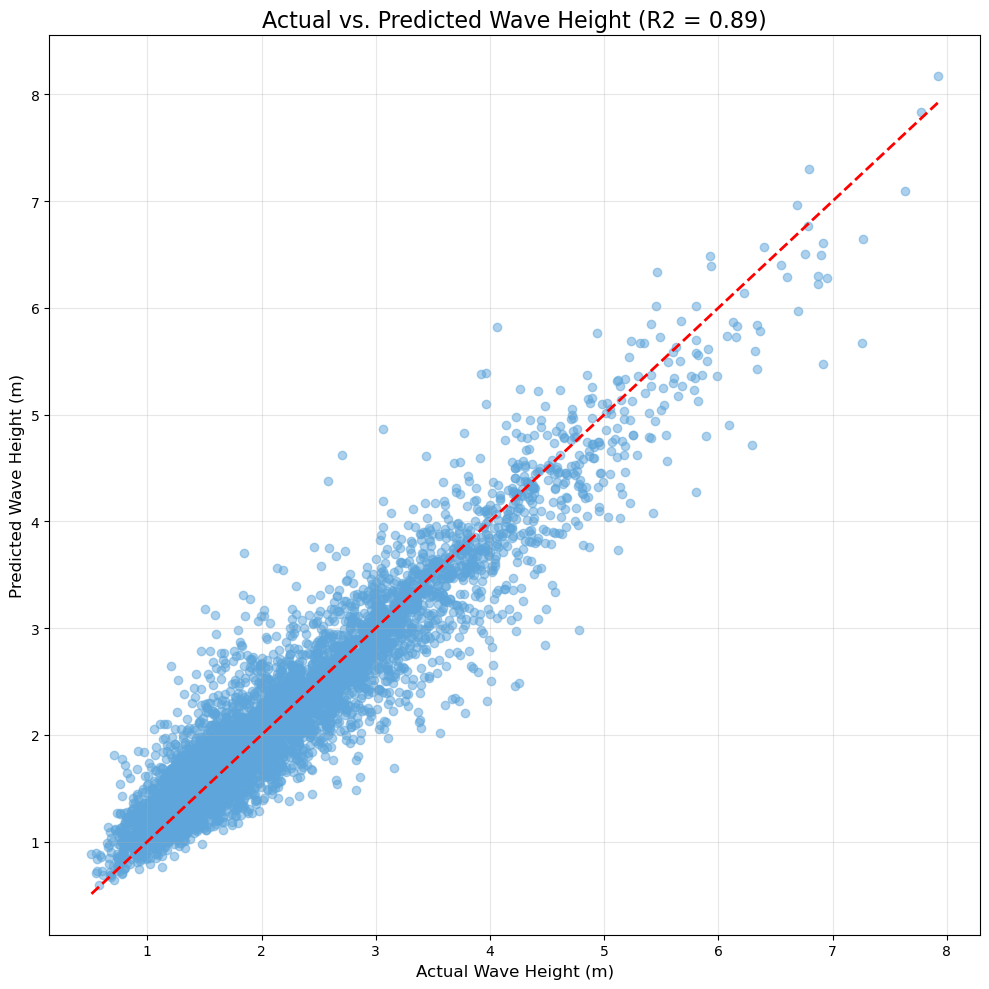

In [28]:
plt.figure(figsize=(10, 10))
plt.scatter(Y_test, Y_pred, alpha=0.5, color='#5DA5DA')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2) 

plt.title(f'Actual vs. Predicted Wave Height (R2 = {r2:.2f})', fontsize=16)
plt.xlabel('Actual Wave Height (m)', fontsize=12)
plt.ylabel('Predicted Wave Height (m)', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('XGBoost_graph.png')
plt.show()

Map for virtual point placement

In [ ]:
import requests
import folium
import json


query = """
[out:json][timeout:25];
(
  way["natural"="coastline"](39.55,-9.15,39.65,-9.05);
);
out geom;
"""


url = "https://overpass-api.de/api/interpreter"
response = requests.get(url, params={'data': query})
data = response.json()


m = folium.Map(location=[39.60, -9.08], zoom_start=13, tiles='OpenStreetMap')


for element in data['elements']:
    if element['type'] == 'way' and 'geometry' in element:
        locations = [[p['lat'], p['lon']] for p in element['geometry']]
        folium.PolyLine(locations, color="blue", weight=2, opacity=0.8).add_to(m)
    elif element['type'] == 'node':
        folium.Marker([element['lat'], element['lon']], popup='Nazaré').add_to(m)


era5_lat, era5_lon = 39.50, -9.55 
folium.CircleMarker(
    location=[era5_lat, era5_lon],
    radius=10,
    color="purple",
    fill=True,
    fill_color="purple",
    popup="ERA5 Data Point (Offshore)"
).add_to(m)


m